# Sensitivity concepts for variance-based analysis

**Leif Rune Hellevik**
NTNU / University of Michigan

First version: **May 28, 2026**  


## Setup

In [1]:
# --- cell: install_chaospy ---
# @title Install chaospy (Colab-friendly)

try:
    import chaospy as cp
    import numpoly
    import numpy as np
    print("chaospy er allerede installert.")
except ImportError:
    # Installer chaospy fra PyPI. Dette drar inn numpoly automatisk.
    %pip install chaospy==4.3.21 --no-cache-dir
    import chaospy as cp
    import numpoly
    import numpy as np

print("numpy  :", np.__version__)
print("numpoly:", numpoly.__version__)
print("chaospy:", cp.__version__)

chaospy er allerede installert.
numpy  : 2.0.2
numpoly: 1.3.9
chaospy: 4.3.21


In [2]:
# --- cell: repo_setup ---
# @title Repo sync and environment setup

import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REMOTE = "https://github.com/lrhgit/uqsa2025.git"
REPO_PATH_COLAB = Path("/content/uqsa2025")

if IN_COLAB:
    if not REPO_PATH_COLAB.exists():
        print("Cloning repository...")
        subprocess.run(
            ["git", "clone", REMOTE, str(REPO_PATH_COLAB)],
            check=True
        )
    else:
        print("Updating existing repository...")
        subprocess.run(
            ["git", "-C", str(REPO_PATH_COLAB), "pull"],
            check=True
        )
    os.chdir(REPO_PATH_COLAB)

# --- Find repo root (works locally + in Colab) ---
cwd = Path.cwd().resolve()
repo_root = next(
    (p for p in [cwd] + list(cwd.parents) if (p / ".git").exists()),
    cwd
)

PY_SRC = repo_root / "python_source"
if PY_SRC.exists() and str(PY_SRC) not in sys.path:
    sys.path.insert(0, str(PY_SRC))

print("CWD:", Path.cwd())
print("repo_root:", repo_root)
print("python_source exists:", PY_SRC.exists())
print("python_source in sys.path:", str(PY_SRC) in sys.path)

Updating existing repository...
CWD: /content/uqsa2025
repo_root: /content/uqsa2025
python_source exists: True
python_source in sys.path: True


In [3]:
# --- cell: layout_and_numpy_patch ---
# @title Layout fix, imports, and NumPy compatibility patch

import warnings
warnings.filterwarnings("ignore")

from IPython.display import HTML

HTML("""
<style>
div.cell.code_cell, div.output {
    max-width: 100% !important;
}
</style>
""")

import numpy as np
import matplotlib.pyplot as plt
import chaospy as cp
import numpoly
import pandas as pd


# Pretty-print helpers (used across notebooks)
from pretty_printing import (
    section_title,
    pretty_table,
    pretty_print_sobol_mc,
    sensitivity_table,
)


# --- NumPy reshape compatibility patch for numpoly ---
_old_reshape = np.reshape

def _reshape_compat(a, *args, **kwargs):
    newshape = None
    if "newshape" in kwargs:
        newshape = kwargs.pop("newshape")
    if "shape" in kwargs and newshape is None:
        newshape = kwargs.pop("shape")
    if newshape is not None:
        return _old_reshape(a, newshape, *args, **kwargs)
    return _old_reshape(a, *args, **kwargs)

np.reshape = _reshape_compat
print("✓ numpy.reshape patched for numpoly compatibility")

✓ numpy.reshape patched for numpoly compatibility


In [4]:
# --- cell: load_problem_helpers ---
import numpy as np
import chaospy as cp

from sensitivity_examples_nonlinear import (
    analytic_sensitivity_coefficients,
)

## From intuition to formal language

In the interactive G* exploration, we observed that some factors matter more than others, and that first-order and total-effect indices may differ.

Variance-based sensitivity analysis provides a formal way to quantify how uncertainty in model inputs contributes to uncertainty in model outputs.

We now connect that intuition to the interpretation of Sobol sensitivity indices.

## Software note

Throughout this workshop we use the Python package Chaospy as a common framework for probability distributions, sampling, Monte Carlo methods, polynomial chaos expansions, and sensitivity analysis.

## Additive linear models

An additive model is a model where the output can be written as a sum of separate contributions from the individual input factors:

$$
Y = \sum_{i=1}^{r} f_i(Z_i),
$$

where each term depends on only one variable.

To build intuition, we consider the simple additive linear model

$$
Y = \sum_{i=1}^{r} \Omega_i Z_i,
$$

where the uncertain inputs $Z_i$ are independent random variables, and the coefficients $\Omega_i$ determine how strongly each factor influences the output.

We assume

$$
Z_i \sim N(0,\sigma_{Z_i}), \qquad i=1,\ldots,r,
$$

so that the output is also normally distributed, with

$$
\bar y = \sum_{i=1}^{r} \Omega_i \bar z_i,
\qquad
\sigma_Y^2 =
\sum_{i=1}^{r} \Omega_i^2 \sigma_{Z_i}^2
.
$$

The model is simple enough that the sensitivity indices can be derived analytically, while still illustrating many of the key ideas behind variance-based sensitivity analysis.

To make the effects visually clear, we order the uncertainties:

$$
\sigma_{Z_1} < \sigma_{Z_2} < \cdots < \sigma_{Z_r}.
$$


In [5]:
def linear_model(Z, omega):
    """
    Z     : input samples, shape (Ns, Nrv)
    omega : coefficients, shape (Nrv,)
    """
    return Z @ omega

In [6]:
Nrv = 4  # number of random variables

mu = np.zeros(Nrv)  # expected value
sigma = np.array([1.0, 2.0, 3.0, 4.0]) #std
omega = np.ones(Nrv) * 2.0  # weights


In [7]:
Ns = 500

# Independent Gaussian input factors
pdfs = [
    cp.Normal(mu_i, sigma_i)
    for mu_i, sigma_i in zip(mu, sigma)
]

jpdf = cp.J(*pdfs)

# Monte Carlo input sample matrix
Z = jpdf.sample(Ns).T   # (Ns, Nrv)

# Model evaluations
Y = linear_model(Z, omega)

After defining the input distributions, we draw a Monte Carlo sample and evaluate the linear model for each sample. This gives paired values of each input factor \(Z_i\) and the corresponding model output \(Y\), which we can inspect using scatterplots.

### Scatterplots as a first diagnostic

Use the sliders to change the coefficients $\Omega_i$, and inspect how the scatterplots change.


In [8]:
   # Interactive scatterplot demo for the linear model
from scatter_demo import scatter_demo

scatter_ui = scatter_demo(Z)
display(scatter_ui)

**Reflection**

Based on the scatterplots:

- Which input appears most influential?  
- Which input appears least influential?  
- Can you rank the inputs by apparent influence?  
- Does the ranking depend only on $\Omega_i$, or also on the spread of $Z_i$?  

The scatterplots suggest that influence depends both on the model coefficient

$\Omega_i$ and on the variability of the input $Z_i$. This motivates sensitivity measures that account for input scaling.

### Normalized derivatives

Raw derivatives measure how strongly the output changes with respect to an input:

$$
\frac{\partial Y}{\partial Z_i}
$$

However, raw derivatives depend on scaling and units, making comparisons between parameters difficult.

A normalized sensitivity measure is obtained by scaling both input and output with their standard deviations:

$$
S_{Z_i}^{\sigma}
=
\frac{\sigma_{Z_i}}{\sigma_Y}
\frac{\partial Y}{\partial Z_i}
\tag{10}
$$

For the linear model,

$$
Y = \sum_{i=1}^{r} \Omega_i Z_i,
$$

the normalized sensitivities become

$$
\left(S_{Z_i}^{\sigma}\right)^2
=
\left(
\frac{\Omega_i \sigma_{Z_i}}
{\sigma_Y}
\right)^2
\tag{11}
$$

This has several attractive properties:

* both the model coefficients $\Omega_i$ and the input variability $\sigma_{Z_i}$ influence the sensitivity
    
* the sensitivities are dimensionless  

* they are directly comparable across parameters  

* for additive linear models:  

$$
\sum_i \left(S_{Z_i}^{\sigma}\right)^2 = 1
$$

The normalized sensitivities therefore provide a natural ranking of parameter importance for the linear model.

In practice, normalized derivative sensitivities require either:

* analytical or numerical evaluation of the derivatives $\partial Y / \partial Z_i$,

* or estimation from local regression or surrogate models.

For complex nonlinear models, obtaining reliable derivatives may itself become computationally demanding.


In [9]:
# @title
# Analytical sensitivity ranking
display(section_title("Analytical sensitivity ranking"))

sensitivity = (omega * sigma) ** 2
sensitivity /= np.sum(sensitivity)

sensitivity_table(
    sensitivity,
    [f"Z{i}" for i in range(1, Nrv + 1)],
    column_name="normalized sensitivity",
)

,normalized sensitivity
Z1,0.033
Z2,0.133
Z3,0.300
Z4,0.533


### From conditional variances to Sobol indices

The scatterplots suggest that influential factors produce visible structure or patterns in the model output $Y$.

To make this idea more quantitative, we may divide the range of an input factor $Z_i$ into slices and examine how the distribution of $Y$ changes from slice to slice.

The interactive plot below illustrates this idea.

In [10]:
from conditional_slices import conditional_slices_interactive

ui = conditional_slices_interactive(Z.T, omega, jpdf)
ui

For a very thin slice, we effectively keep $Z_i$ fixed while averaging over all remaining uncertain inputs. This corresponds to the conditional expectation

$$
E_{Z_{\sim i}}(Y \mid Z_i),
$$

where $Z_{\sim i}$ denotes all variables except $Z_i$.

If this conditional expectation varies strongly with $Z_i$, the factor is influential. A natural quantitative measure is therefore the conditional variance

$$
V_{Z_i}\!\left(E_{Z_{\sim i}}(Y \mid Z_i)\right).
$$

The first-order Sobol sensitivity index is this conditional variance normalized by the total output variance:

$$
S_i
=
\frac{
V_{Z_i}\!\left(E_{Z_{\sim i}}(Y \mid Z_i)\right)
}{
V(Y)
}.
$$

A large value of $S_i$ indicates that $Z_i$ explains a large fraction of the output variability.

#### Connection to normalized derivatives for additive linear models

For the additive linear model,

$$
Y = \sum_{i=1}^r \Omega_i Z_i,
$$

there are no interaction terms. The first-order Sobol indices therefore account for all output variance, and reduce to

$$
S_i
=
\frac{\Omega_i^2 \sigma_{Z_i}^2}{\sigma_Y^2}.
$$

Using the normalized derivative sensitivity measure introduced earlier,

$$
S_{Z_i}^{\sigma}
=
\frac{\sigma_{Z_i}}{\sigma_Y}
\frac{\partial Y}{\partial Z_i},
$$

and noting that

$$
\frac{\partial Y}{\partial Z_i} = \Omega_i,
$$

we obtain

$$
S_i
=
\left(
S_{Z_i}^{\sigma}
\right)^2.
$$

Thus, for additive linear models, the first-order Sobol indices are identical to the squared normalized derivative sensitivities.

## Interaction models

We now consider a model where both the input factors and the model coefficients are uncertain:

$$
Y = \sum_{i=1}^{r} \Omega_i Z_i.
$$

Here, the influence of $Z_i$ depends on the value of $\Omega_i$, and the influence of $\Omega_i$ depends on the value of $Z_i$. The model therefore contains interaction effects.

We use

$$
Z_i \sim N(0,\sigma_{Z_i}),
\qquad
\Omega_i \sim N(\mu_{\Omega_i},\sigma_{\Omega_i}),
\qquad i=1,\ldots,r.
$$

Unlike the additive linear model, first-order sensitivity indices no longer capture the full contribution from each factor.


### Scatterplots for the interaction model

We first inspect the model visually. The upper row shows $Y$ versus the input factors $Z_i$, while the lower row shows $Y$ versus the uncertain coefficients $\Omega_i$.

The key question is whether visual influence in a scatterplot is the same as first-order sensitivity.

In [11]:
# Interaction model: samples and scatterplots

N_plot = 250
Nrv = 4

mu_z = np.zeros(Nrv)
sigma_z = np.array([1.0, 2.0, 3.0, 4.0])

mu_omega = np.ones(Nrv) * 2.0
sigma_omega = np.array([0.5, 1.0, 2.0, 4.0])

pdfs = [
    *[cp.Normal(m, s) for m, s in zip(mu_z, sigma_z)],
    *[cp.Normal(m, s) for m, s in zip(mu_omega, sigma_omega)],
]

jpdf_interaction = cp.J(*pdfs)

X = jpdf_interaction.sample(N_plot, rule="random").T

Z = X[:, :Nrv]
Omega = X[:, Nrv:]

Y = np.sum(Omega * Z, axis=1)

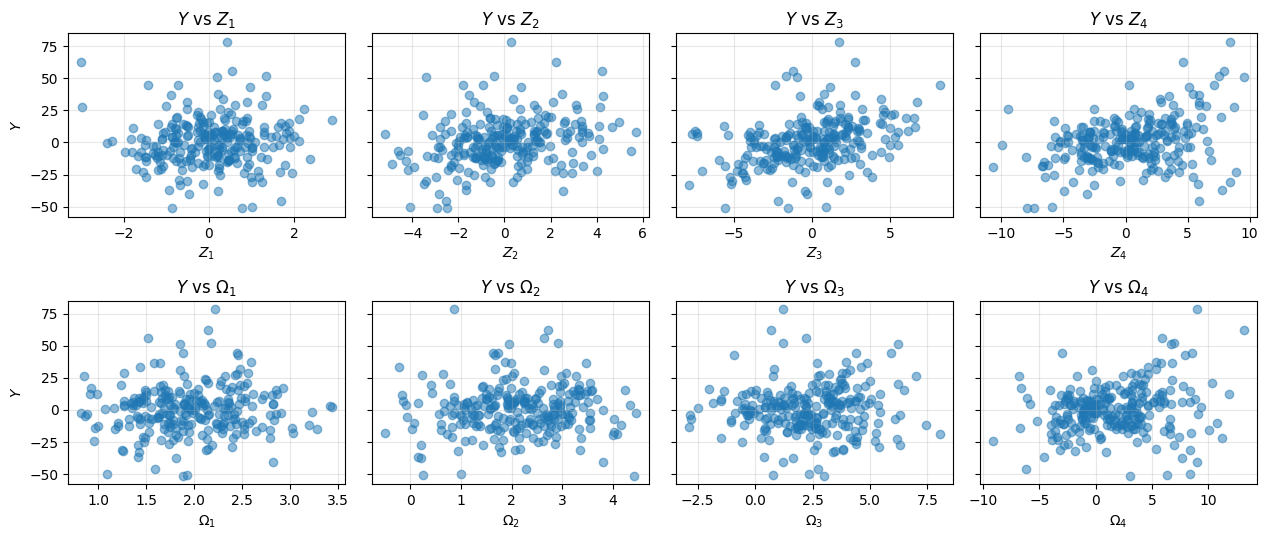

In [12]:
# @title
# Scatterplots for interaction model

fig, axs = plt.subplots(2, Nrv, figsize=(3.2 * Nrv, 5.5), sharey=True)

for i in range(Nrv):
    axs[0, i].scatter(Z[:, i], Y, alpha=0.5)
    axs[0, i].set_xlabel(f"$Z_{i+1}$")
    axs[0, i].set_title(f"$Y$ vs $Z_{i+1}$")

    axs[1, i].scatter(Omega[:, i], Y, alpha=0.5)
    axs[1, i].set_xlabel(f"$\\Omega_{i+1}$")
    axs[1, i].set_title(f"$Y$ vs $\\Omega_{i+1}$")

axs[0, 0].set_ylabel("$Y$")
axs[1, 0].set_ylabel("$Y$")

for ax in axs.ravel():
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

**Reflection**

In the model

$$
Y = \sum_{i=1}^{r} \Omega_i Z_i,
$$

the variables $Z_i$ and $\Omega_i$ appear symmetrically in the product terms.

- Why do the scatterplots for $Z_i$ and $\Omega_i$ look so different?
- Which variables seem to have strong first-order effects?
- Which variables mainly contribute through interactions?
- What is the fundamental difference between varying an input factor $Z_i$ and varying a coefficient $\Omega_i$?

### Analytical first-order and total-effect indices

We now compute the analytical first-order and total-effect Sobol indices for the interaction model.

The key question is whether the conclusions from the scatterplots agree with the variance-based sensitivity indices.


In [13]:
# @title
# Analytical first-order and total-effect indices

VarY = np.sum(sigma_z**2 * (mu_omega**2 + sigma_omega**2))

S_Z = mu_omega**2 * sigma_z**2 / VarY
S_Omega = np.zeros_like(S_Z)

ST_Z = (mu_omega**2 + sigma_omega**2) * sigma_z**2 / VarY
ST_Omega = sigma_omega**2 * sigma_z**2 / VarY

labels = [f"Z{i}" for i in range(1, Nrv + 1)] + [
    f"Ω{i}" for i in range(1, Nrv + 1)
]

S_first = np.concatenate([S_Z, S_Omega])
S_total = np.concatenate([ST_Z, ST_Omega])

df_interaction = pd.DataFrame(
    {
        "first-order": S_first,
        "total-effect": S_total,
    },
    index=labels,
)

pretty_table(df_interaction)

,first-order,total-effect
Z1,0.010,0.010
Z2,0.038,0.048
Z3,0.086,0.173
Z4,0.154,0.769
Ω1,0.000,0.001
Ω2,0.000,0.010
Ω3,0.000,0.086
Ω4,0.000,0.615


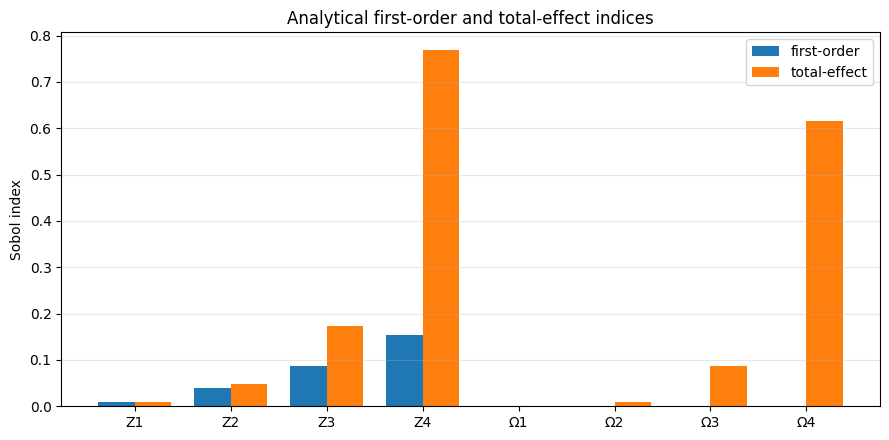

In [14]:
# @title
# Bar plot: first-order vs total-effect indices

x = np.arange(len(labels))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.bar(
    x - width/2,
    S_first,
    width,
    label="first-order",
)

ax.bar(
    x + width/2,
    S_total,
    width,
    label="total-effect",
)

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel("Sobol index")

ax.set_title(
    "Analytical first-order and total-effect indices"
)

ax.legend()

ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()

plt.show()

### Why total-effect indices?

For interaction models, first-order indices alone are no longer sufficient. A variable may contribute little on its own, yet still be important through interactions with other variables.

The total-effect index $S_{T_i}$ measures everything involving variable $X_i$:

$$
\begin{aligned}
S_{T_i}
&=
S_i
+
\sum_{j \neq i} S_{ij}
+
\sum_{\substack{j<k \\ j,k \neq i}} S_{ijk}
+
\cdots
\end{aligned}
$$

Thus, $S_{T_i}$ includes both the direct effect of $X_i$ and all interaction effects involving $X_i$.

A large gap between $S_{T_i}$ and $S_i$ therefore indicates strong interactions.

In principle, the full variance decomposition contains all higher-order interaction terms:

$$
1
=
\sum_i S_i
+
\sum_{i<j} S_{ij}
+
\sum_{i<j<k} S_{ijk}
+
\cdots
$$

However, for a model with $k$ uncertain inputs, the complete decomposition contains $2^k-1$ terms. The number of interaction indices therefore grows exponentially with the number of uncertain inputs.

For many practical applications, the pair $(S_i,S_{T_i})$ is therefore sufficient:

- $S_i$ identifies important main effects,

- $S_{T_i}$ identifies variables that matter either directly or through interactions.

## Computing $S_{T_i}$ in practice

A key advantage of the total-effect index is that it can be estimated directly, without explicitly computing all higher-order interaction terms.

#### Monte Carlo methods

With Monte Carlo methods, $S_i$ and $S_{T_i}$ can be estimated from the same Saltelli sampling scheme, with cost scaling approximately as

$$
O(N(d+2)),
$$

where $N$ is the number of samples and $d$ the number of uncertain inputs.

#### Polynomial chaos expansions

With polynomial chaos expansions, Sobol indices can be extracted directly from the polynomial coefficients once the surrogate has been constructed.

Thus, both Monte Carlo methods and PCE allow efficient computation of first-order and total-effect indices without explicitly evaluating all higher-order interaction terms.

## Take-away messages

Variance-based sensitivity analysis provides a quantitative framework for understanding how uncertainty propagates through mathematical models.

For additive models:

* first-order Sobol indices fully describe the variance contributions,
* normalized derivatives and Sobol indices become closely related.

For interaction models:

* first-order indices alone are no longer sufficient,
* total-effect indices reveal variables that contribute mainly through interactions,
* a large gap between $S_i$ and $S_{T_i}$ indicates important interaction effects.

In practice, the pair $(S_i,S_{T_i})$ is often sufficient to identify:

* variables with strong direct influence,
* variables that matter primarily through interactions,
* variables that can potentially be fixed or simplified.

The following notebooks show how these indices can be estimated numerically using Monte Carlo sampling and polynomial chaos expansions.
